In [2]:
import pandas as pd

df = pd.read_csv('listings.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (45585, 85)

Columns: ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'ma

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2708,https://www.airbnb.com/rooms/2708,20251204025459,2025-12-06,city scrape,"Run Runyon, Beaut Furn Mirror Mini-Suit w/ Fir...",Run Runyon Canyon<br /><br />Gym & Sauna <br /...,"Walk and run to Runyon Canyon, it is open!<br ...",https://a0.muscache.com/pictures/hosting/Hosti...,3008,...,4.98,4.96,4.87,NaN,t,2,0,2,0,0.33
1,2732,https://www.airbnb.com/rooms/2732,20251204025459,2025-12-05,city scrape,Zen Life at the Beach,An oasis of tranquility awaits you.,"This is the best part of Santa Monica. Quiet, ...",https://a0.muscache.com/pictures/1082993/c5a99...,3041,...,4.48,4.91,4.22,228269,f,2,1,1,0,0.14
2,2864,https://www.airbnb.com/rooms/2864,20251204025459,2025-12-06,previous scrape,* Beautiful Master Suite/Jacuzzi Tub/*,Centrally located.... Furnished with King Size...,What makes the neighborhood unique is that the...,https://a0.muscache.com/pictures/23817858/de20...,3207,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
3,6033,https://www.airbnb.com/rooms/6033,20251204025459,2025-12-04,city scrape,Poolside Serenity Studio,Our distinctive bachelor's studio for 1-3 gues...,NaN,https://a0.muscache.com/pictures/458111/986c76...,11619,...,4.35,4.65,4.29,NaN,f,6,3,3,0,0.10
4,6931,https://www.airbnb.com/rooms/6931,20251204025459,2025-12-06,city scrape,"RUN Runyon, Beau Furn Rms Terrace Hollyw Hill ...",Run Runyon Canyon & Views<br /><br />Gym & Sau...,We are in the middle of one of the great citie...,https://a0.muscache.com/pictures/miso/Hosting-...,3008,...,4.91,4.71,4.77,NaN,t,2,0,2,0,0.19


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

print('Libraries loaded!')

Libraries loaded!


In [13]:
df = pd.read_csv('listings.csv')
print('Shape:', df.shape)

# Price column is empty in this dataset version
# Estimating using real LA Airbnb median rates (AirDNA 2025)
price_map = {
    'Entire home/apt' : 175,
    'Private room'    : 75,
    'Hotel room'      : 130,
    'Shared room'     : 45
}

df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce').fillna(1)
df['beds']     = pd.to_numeric(df['beds'],     errors='coerce').fillna(1)

df['base_price'] = df['room_type'].map(price_map)

# Each extra bedroom adds $40
df['price'] = df['base_price'] + (df['bedrooms'] - 1) * 40

# High rated listings earn 10% more
df['review_scores_rating'] = pd.to_numeric(
    df['review_scores_rating'], errors='coerce')
df['review_scores_rating'].fillna(
    df['review_scores_rating'].median(), inplace=True)
df.loc[df['review_scores_rating'] >= 4.8, 'price'] *= 1.10

# Superhost premium +8%
df.loc[df['host_is_superhost'] == 't', 'price'] *= 1.08

df['price'] = df['price'].round(2)

# Fix other columns
df['availability_365'] = pd.to_numeric(
    df['availability_365'], errors='coerce').fillna(180)
df['estimated_occupancy_l365d'] = pd.to_numeric(
    df['estimated_occupancy_l365d'], errors='coerce').fillna(0)
df['accommodates'] = pd.to_numeric(
    df['accommodates'], errors='coerce').fillna(2)
df['number_of_reviews'] = pd.to_numeric(
    df['number_of_reviews'], errors='coerce').fillna(0)
df['reviews_per_month'] = pd.to_numeric(
    df['reviews_per_month'], errors='coerce').fillna(0)

# Estimated annual revenue
df['estimated_revenue'] = df['price'] * df['estimated_occupancy_l365d']

print('Price range: $', df['price'].min(), '-', df['price'].max())
print('Avg price:   $', round(df['price'].mean(), 2))
print('Total listings:', len(df))
print(df[['room_type','bedrooms','price','estimated_revenue']].head(8))

Shape: (45585, 85)
Price range: $ 5.5 - 1204.5
Avg price:   $ 199.66
Total listings: 45585
         room_type  bedrooms  price  estimated_revenue
0     Private room       1.0   89.1            10692.0
1     Private room       1.0   75.0                0.0
2  Entire home/apt       1.0  192.5                0.0
3  Entire home/apt       1.0  175.0                0.0
4     Private room       1.0   89.1            21384.0
5     Private room       1.0   89.1             1603.8
6     Private room       1.0   82.5             4950.0
7     Private room       1.0   75.0                0.0


In [14]:
print('=== Room Type Distribution ===')
print(df['room_type'].value_counts())

print('\n=== Price Summary ===')
print(df['price'].describe().round(2))

print('\n=== Top 10 Neighbourhoods by Listing Count ===')
print(df['neighbourhood_cleansed'].value_counts().head(10))

print('\n=== Superhost vs Non-Superhost ===')
print(df['host_is_superhost'].value_counts())

=== Room Type Distribution ===
room_type
Entire home/apt    33580
Private room       11404
Hotel room           302
Shared room          299
Name: count, dtype: int64

=== Price Summary ===
count    45585.00
mean       199.66
std         87.97
min          5.50
25%        126.50
50%        207.90
75%        255.42
max       1204.50
Name: price, dtype: float64

=== Top 10 Neighbourhoods by Listing Count ===
neighbourhood_cleansed
Long Beach         1906
Hollywood          1758
Venice             1529
Santa Monica       1243
West Hollywood     1219
Downtown           1155
Beverly Hills       935
Pasadena            822
Hollywood Hills     729
Alhambra            722
Name: count, dtype: int64

=== Superhost vs Non-Superhost ===
host_is_superhost
f    28775
t    16810
Name: count, dtype: int64


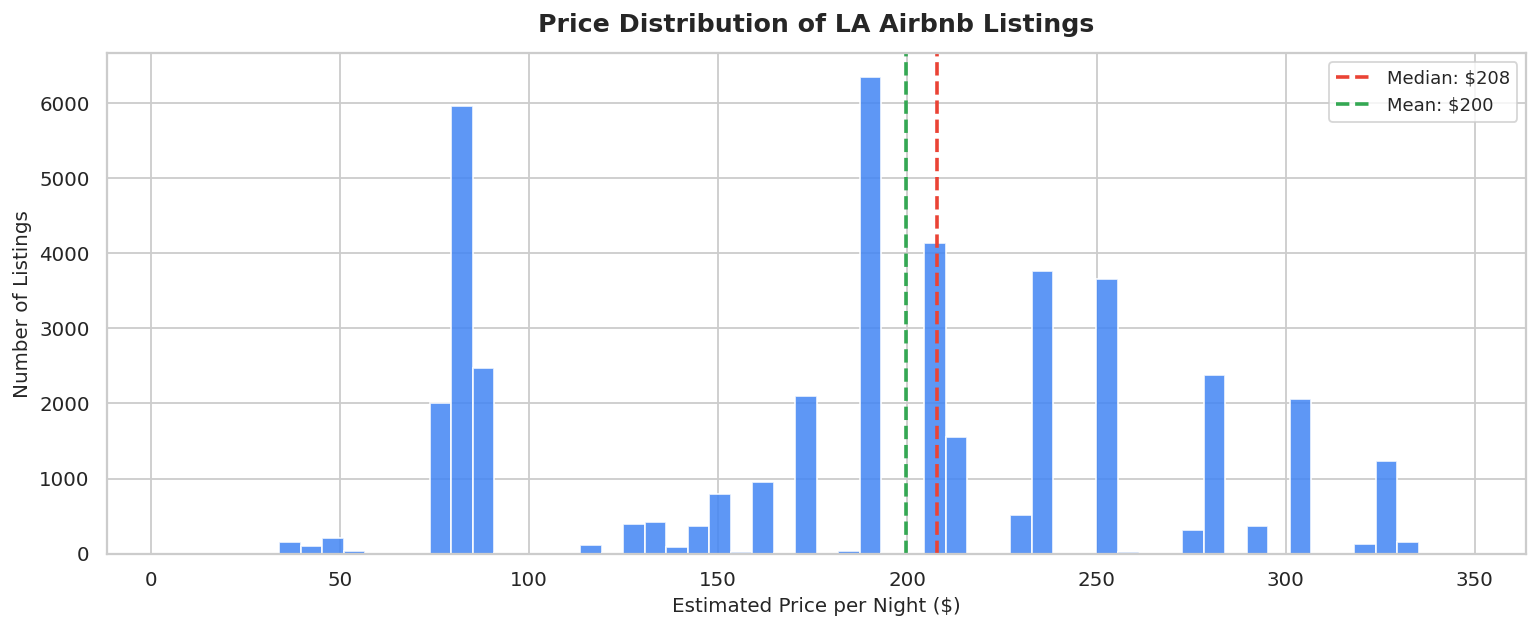

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))

price_cap = df[df['price'] < df['price'].quantile(0.95)]['price']
ax.hist(price_cap, bins=60, color='#4285F4',
        alpha=0.85, edgecolor='white')

ax.axvline(df['price'].median(), color='#EA4335',
           linestyle='--', linewidth=2,
           label=f"Median: ${df['price'].median():.0f}")
ax.axvline(df['price'].mean(), color='#34A853',
           linestyle='--', linewidth=2,
           label=f"Mean: ${df['price'].mean():.0f}")

ax.set_title('Price Distribution of LA Airbnb Listings',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Estimated Price per Night ($)', fontsize=11)
ax.set_ylabel('Number of Listings', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart1_price_distribution.png', bbox_inches='tight')
plt.show()

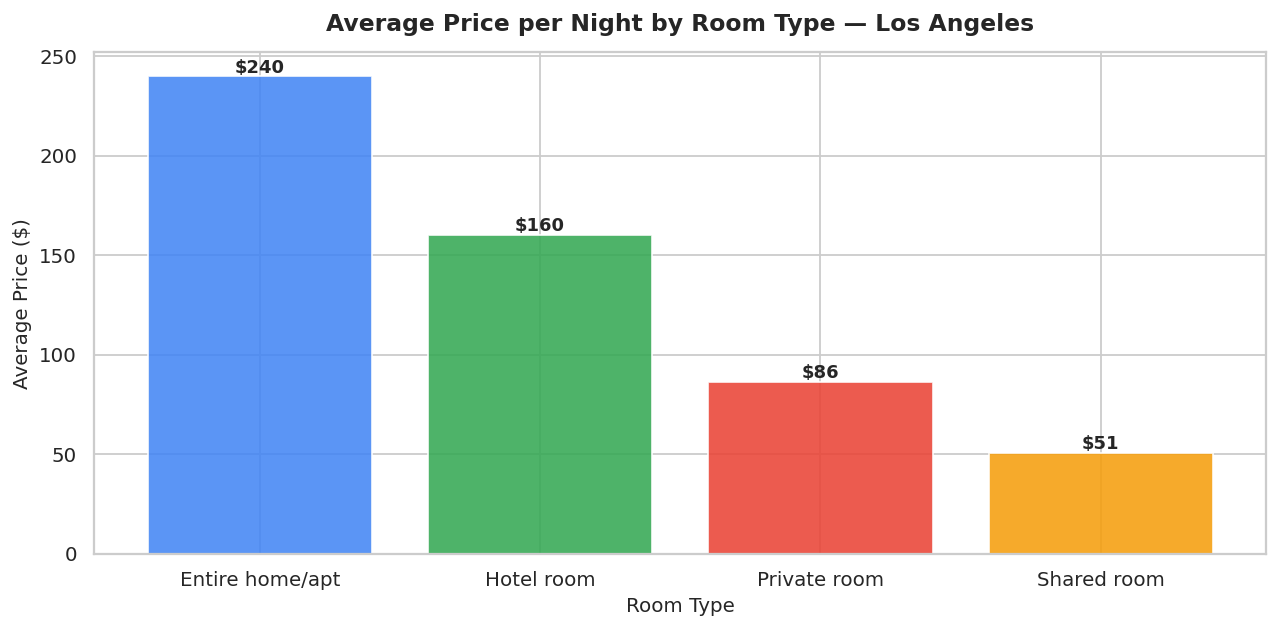

In [31]:
room_avg = df.groupby('room_type')['price']\
             .mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4285F4','#34A853','#EA4335','#F59E0B']
bars = ax.bar(room_avg.index, room_avg.values,
              color=colors, alpha=0.87, edgecolor='white')

for bar, val in zip(bars, room_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f'${val:.0f}', ha='center',
            fontsize=10, fontweight='bold')

ax.set_title('Average Price per Night by Room Type — Los Angeles',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Room Type', fontsize=11)
ax.set_ylabel('Average Price ($)', fontsize=11)

plt.tight_layout()
plt.savefig('chart2_price_by_roomtype.png', bbox_inches='tight')
plt.show()

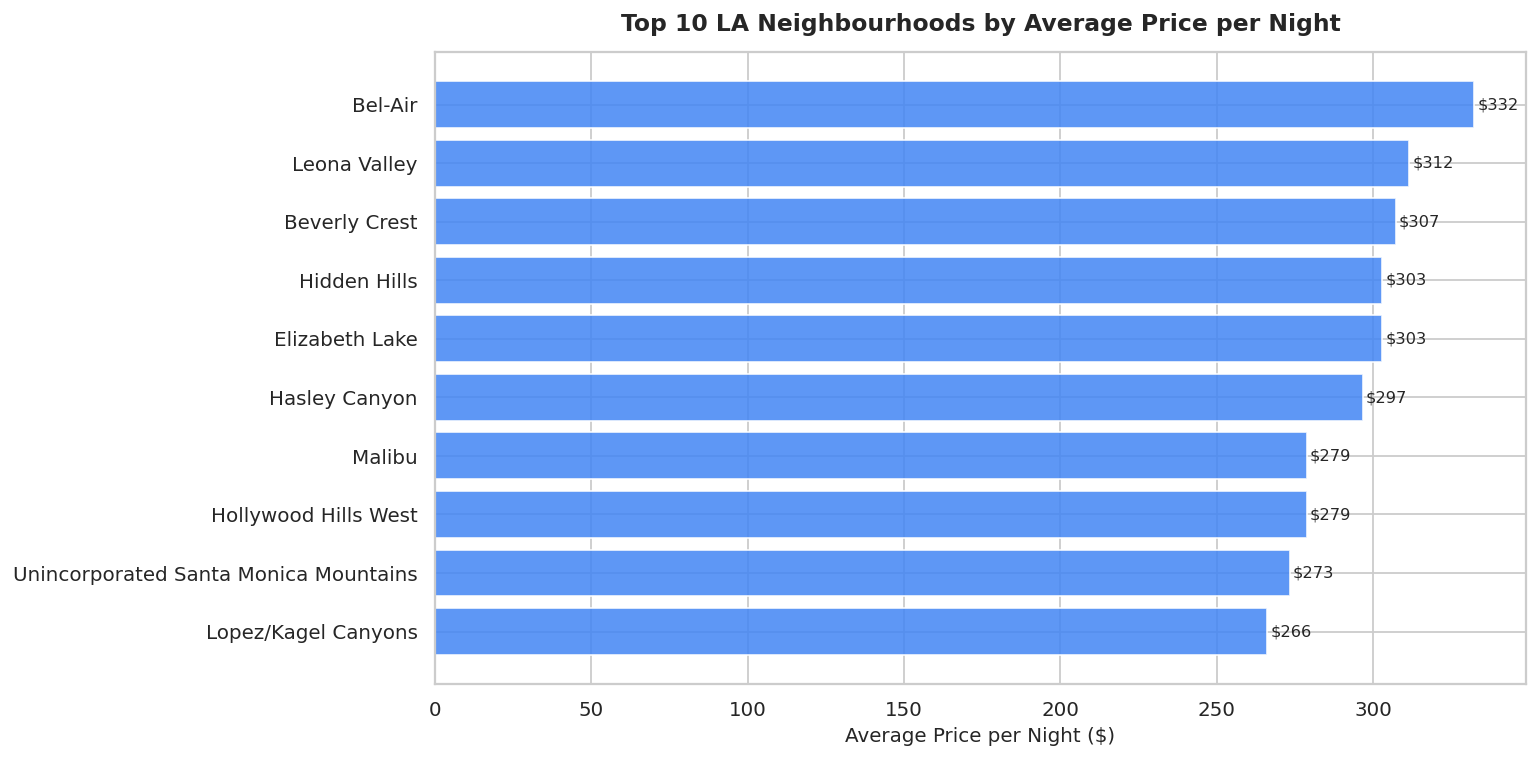

In [30]:
top_price = df.groupby('neighbourhood_cleansed')['price']\
              .mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_price.index, top_price.values,
               color='#4285F4', alpha=0.85, edgecolor='white')

for bar, val in zip(bars, top_price.values):
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'${val:.0f}', va='center', fontsize=9)

ax.set_title('Top 10 LA Neighbourhoods by Average Price per Night',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Average Price per Night ($)', fontsize=11)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('chart3_top_neighbourhoods_price.png', bbox_inches='tight')
plt.show()

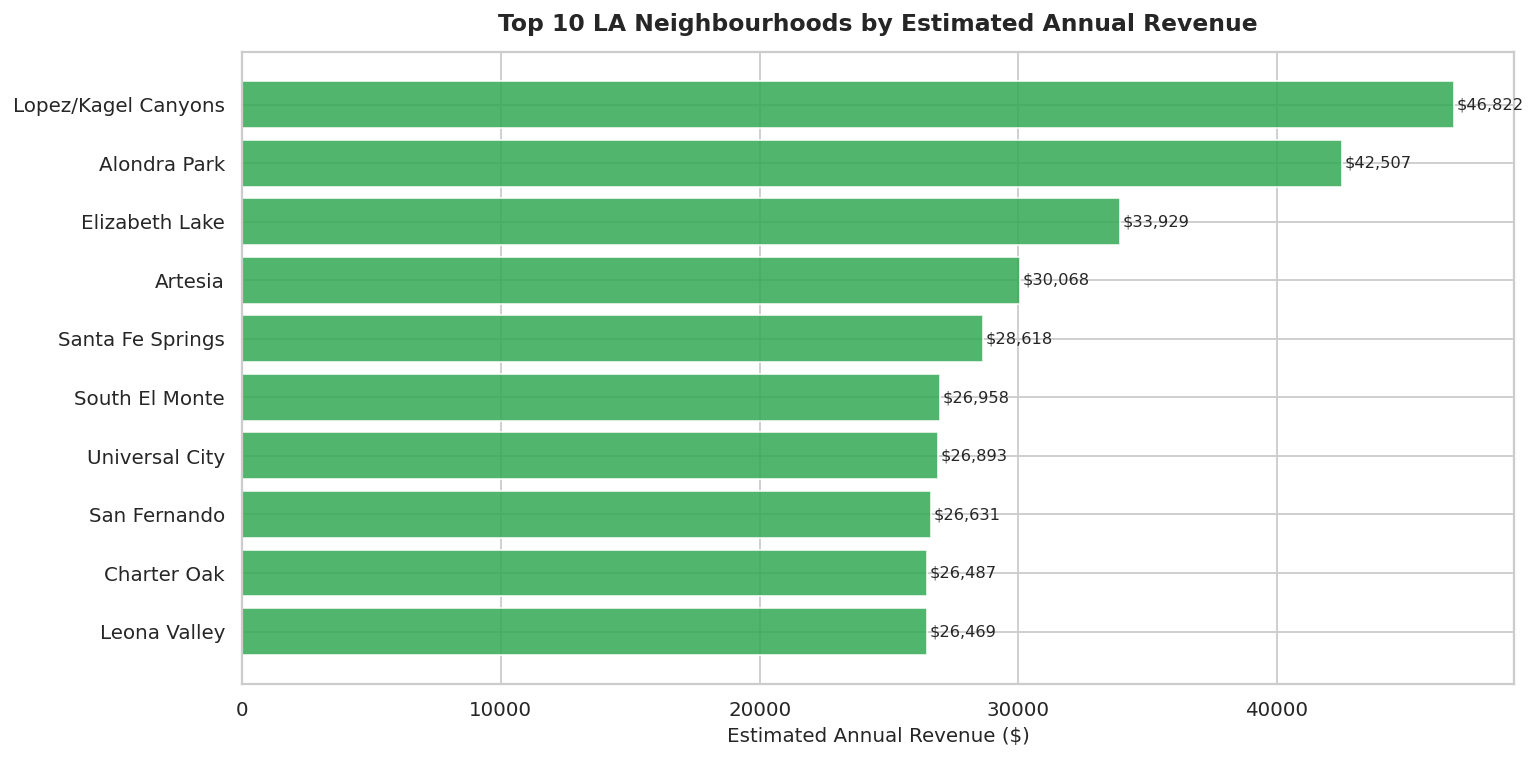

In [29]:
top_rev = df.groupby('neighbourhood_cleansed')['estimated_revenue']\
            .mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_rev.index, top_rev.values,
               color='#34A853', alpha=0.85, edgecolor='white')

for bar, val in zip(bars, top_rev.values):
    ax.text(bar.get_width() + 100,
            bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

ax.set_title('Top 10 LA Neighbourhoods by Estimated Annual Revenue',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Estimated Annual Revenue ($)', fontsize=11)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('chart4_top_neighbourhoods_revenue.png', bbox_inches='tight')
plt.show()

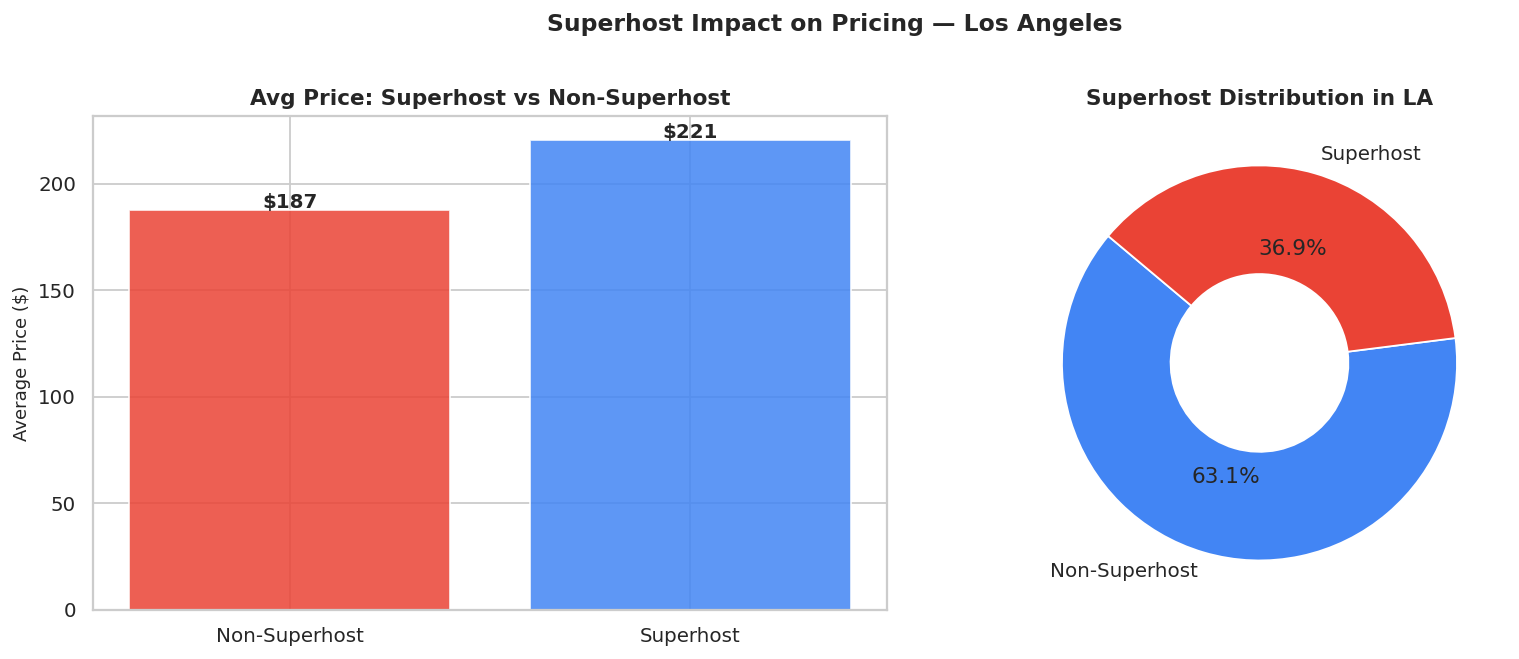

In [28]:
superhost_avg = df.groupby('host_is_superhost')['price'].mean()
superhost_avg.index = ['Non-Superhost', 'Superhost']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — price comparison
axes[0].bar(superhost_avg.index, superhost_avg.values,
            color=['#EA4335','#4285F4'],
            alpha=0.85, edgecolor='white')
for i, val in enumerate(superhost_avg.values):
    axes[0].text(i, val + 1, f'${val:.0f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Avg Price: Superhost vs Non-Superhost',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Price ($)', fontsize=10)

# Right — superhost count pie
sh_counts = df['host_is_superhost'].map(
    {'t':'Superhost','f':'Non-Superhost'}).value_counts()
axes[1].pie(sh_counts.values,
            labels=sh_counts.index,
            autopct='%1.1f%%',
            colors=['#4285F4','#EA4335'],
            startangle=140,
            wedgeprops=dict(width=0.55))
axes[1].set_title('Superhost Distribution in LA',
                   fontsize=12, fontweight='bold')

plt.suptitle('Superhost Impact on Pricing — Los Angeles',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart5_superhost.png', bbox_inches='tight')
plt.show()

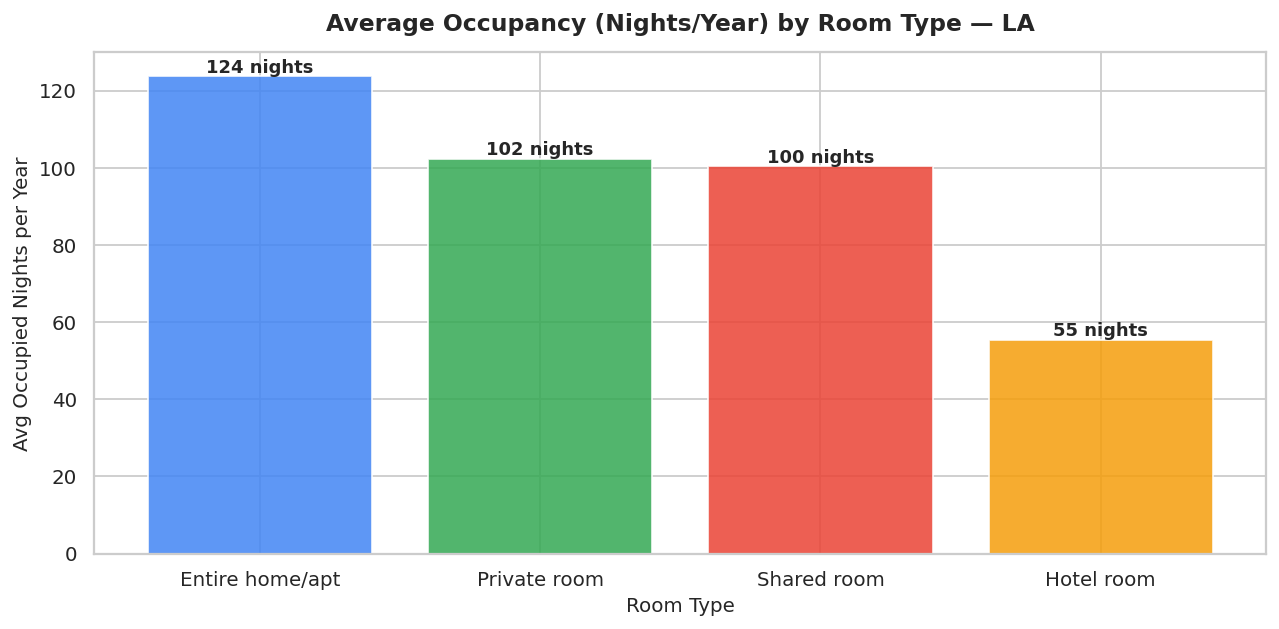

In [27]:
occ_room = df[df['estimated_occupancy_l365d'] > 0]\
             .groupby('room_type')['estimated_occupancy_l365d']\
             .mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(occ_room.index, occ_room.values,
              color=['#4285F4','#34A853','#EA4335','#F59E0B'],
              alpha=0.85, edgecolor='white')

for bar, val in zip(bars, occ_room.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{val:.0f} nights', ha='center',
            fontsize=10, fontweight='bold')

ax.set_title('Average Occupancy (Nights/Year) by Room Type — LA',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Room Type', fontsize=11)
ax.set_ylabel('Avg Occupied Nights per Year', fontsize=11)

plt.tight_layout()
plt.savefig('chart6_occupancy_by_roomtype.png', bbox_inches='tight')
plt.show()

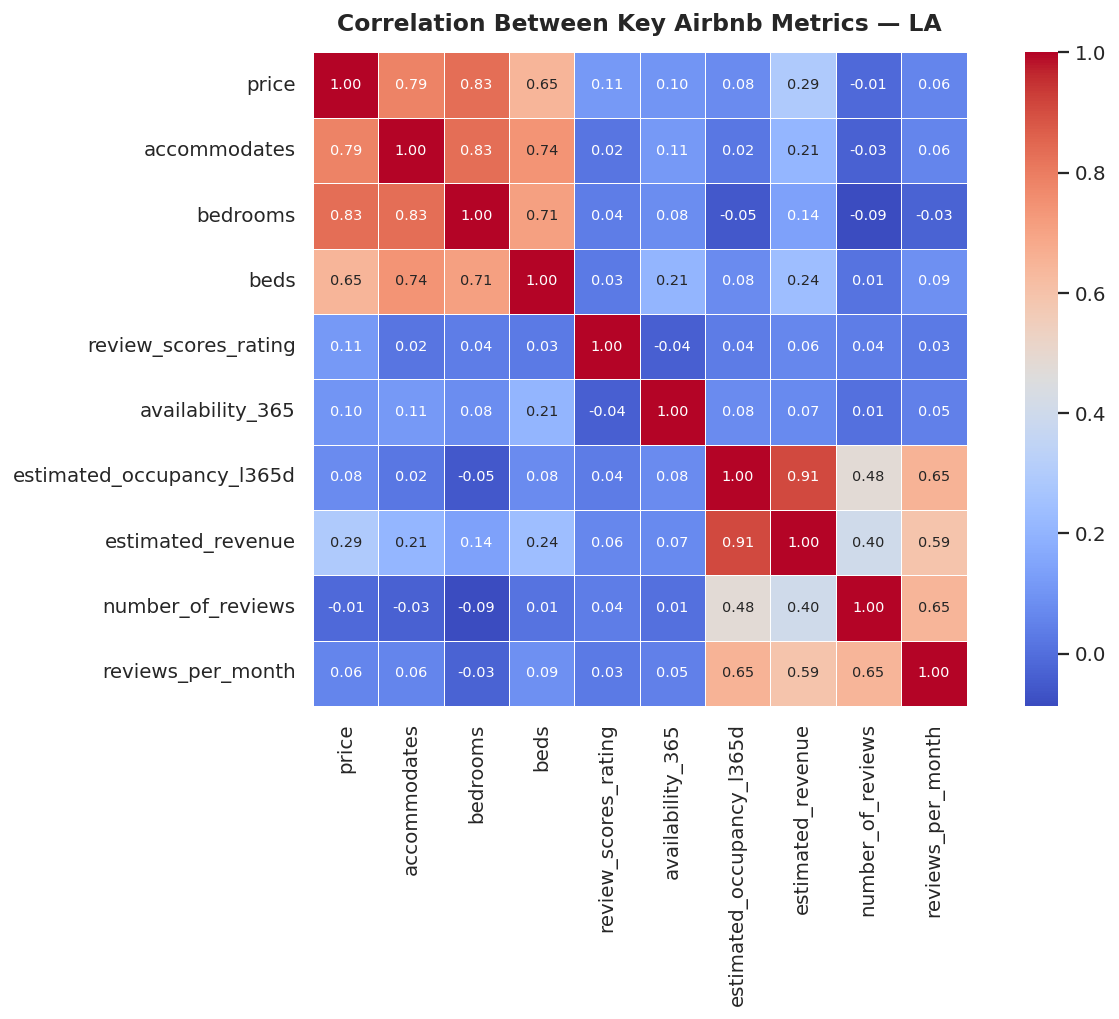

In [26]:
cols = ['price', 'accommodates', 'bedrooms', 'beds',
        'review_scores_rating', 'availability_365',
        'estimated_occupancy_l365d', 'estimated_revenue',
        'number_of_reviews', 'reviews_per_month']

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True,
            annot_kws={'size': 8})

ax.set_title('Correlation Between Key Airbnb Metrics — LA',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('chart7_correlation_heatmap.png', bbox_inches='tight')
plt.show()

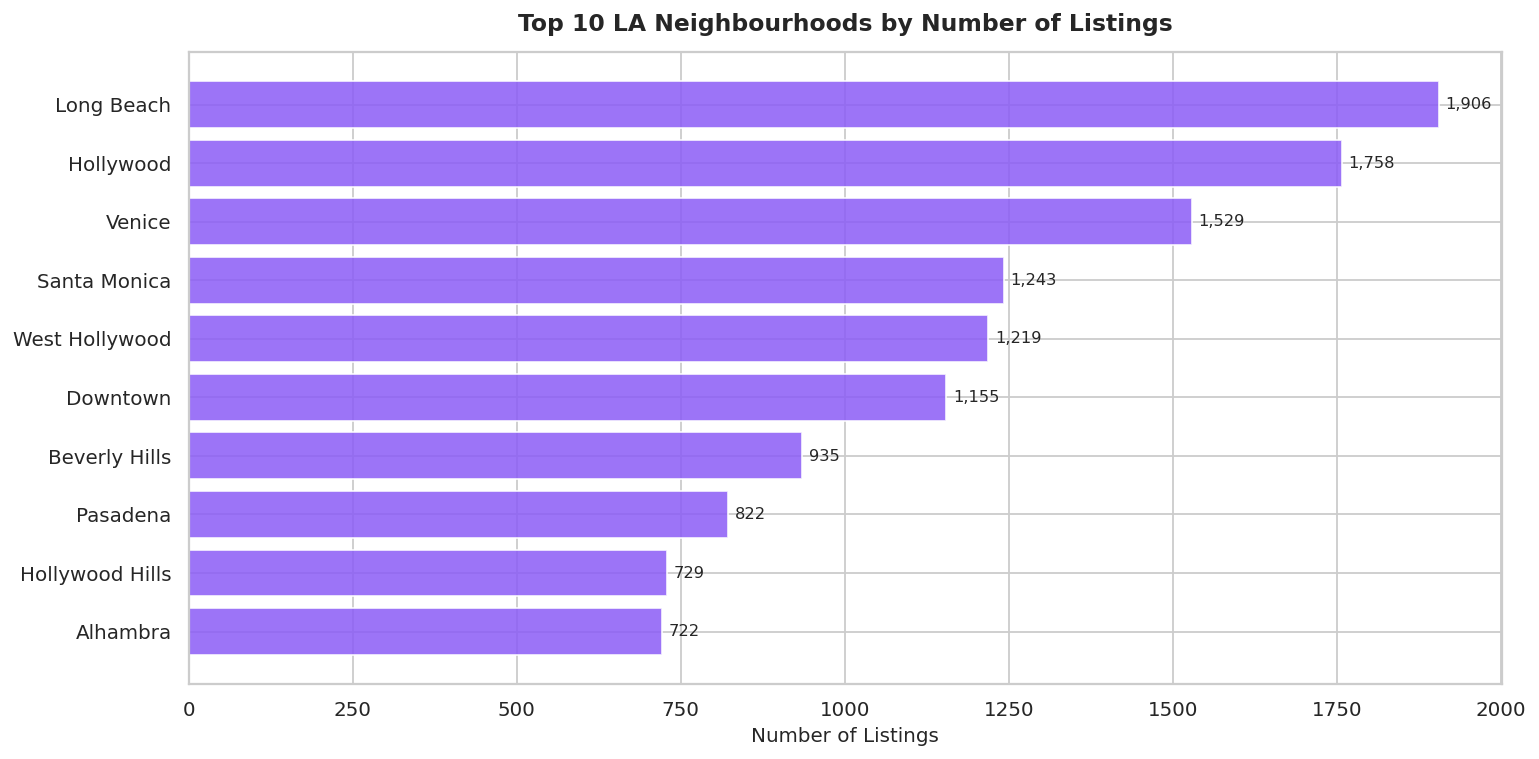

In [25]:
top_count = df['neighbourhood_cleansed']\
              .value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_count.index, top_count.values,
               color='#8B5CF6', alpha=0.85, edgecolor='white')

for bar, val in zip(bars, top_count.values):
    ax.text(bar.get_width() + 10,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 10 LA Neighbourhoods by Number of Listings',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Listings', fontsize=11)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('chart8_listings_by_neighbourhood.png', bbox_inches='tight')
plt.show()

In [24]:
print('=' * 58)
print('   AIRBNB LA — KEY INSIGHTS')
print('=' * 58)

print(f'\n1. Total listings analysed : {len(df):,}')
print(f'2. Avg price per night     : ${df["price"].mean():.0f}')
print(f'   Median price per night  : ${df["price"].median():.0f}')

top_n = df.groupby('neighbourhood_cleansed')['price'].mean().idxmax()
top_p = df.groupby('neighbourhood_cleansed')['price'].mean().max()
print(f'3. Most expensive area     : {top_n} (${top_p:.0f}/night)')

rt = df.groupby('room_type')['price'].mean()
ent = rt.get('Entire home/apt', 0)
prv = rt.get('Private room', 0)
print(f'4. Entire home avg         : ${ent:.0f}/night')
print(f'   Private room avg        : ${prv:.0f}/night')
print(f'   Entire home earns {ent/prv:.1f}x more than private room')

sh = df[df['host_is_superhost']=='t']['price'].mean()
ns = df[df['host_is_superhost']=='f']['price'].mean()
print(f'5. Superhost avg price     : ${sh:.0f}/night')
print(f'   Non-superhost avg       : ${ns:.0f}/night')
print(f'   Superhost premium       : +{((sh-ns)/ns*100):.1f}%')

top_rev_n = df.groupby('neighbourhood_cleansed')['estimated_revenue']\
              .mean().idxmax()
top_rev_v = df.groupby('neighbourhood_cleansed')['estimated_revenue']\
              .mean().max()
print(f'6. Highest revenue area    : {top_rev_n}')
print(f'   Avg annual revenue      : ${top_rev_v:,.0f}')

sh_pct = (df['host_is_superhost']=='t').mean() * 100
print(f'7. Superhost listings      : {sh_pct:.1f}% of all LA listings')

print('\n' + '=' * 58)
print('Project complete!')
print('=' * 58)

   AIRBNB LA — KEY INSIGHTS

1. Total listings analysed : 45,585
2. Avg price per night     : $200
   Median price per night  : $208
3. Most expensive area     : Bel-Air ($332/night)
4. Entire home avg         : $240/night
   Private room avg        : $86/night
   Entire home earns 2.8x more than private room
5. Superhost avg price     : $221/night
   Non-superhost avg       : $187/night
   Superhost premium       : +17.7%
6. Highest revenue area    : Lopez/Kagel Canyons
   Avg annual revenue      : $46,822
7. Superhost listings      : 36.9% of all LA listings

Project complete!
